In [5]:
import pennylane as qml
import numpy as np
import jax
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
jnp = jax.numpy

In [6]:
def two_qubit_decomp(params, wires):
    """Implement an arbitrary SU(4) gate on two qubits
    using the decomposition from Theorem 5 in
    https://arxiv.org/pdf/quant-ph/0308006.pdf"""
    i, j = wires
    # Single U(2) parameterization on both qubits separately
    qml.Rot(*params[:3], wires=i)
    qml.Rot(*params[3:6], wires=j)
    qml.CNOT(wires=[j, i])  # First CNOT
    qml.RZ(params[6], wires=i)
    qml.RY(params[7], wires=j)
    qml.CNOT(wires=[i, j])  # Second CNOT
    qml.RY(params[8], wires=j)
    qml.CNOT(wires=[j, i])  # Third CNOT
    # Single U(2) parameterization on both qubits separately
    qml.Rot(*params[9:12], wires=i)
    qml.Rot(*params[12:15], wires=j)


# The three building blocks on two qubits we will compare are:
operations = {
    ("Decomposition", "decomposition"): two_qubit_decomp,
    ("PauliRot sequence",) * 2: qml.ArbitraryUnitary,
    ("$\mathrm{SU}(N)$ gate", "SU(N) gate"): qml.SpecialUnitary,
}

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\DELL\AppData\Local\Temp\ipykernel_19864\391022573.py:24: SyntaxWarning: invalid escape sequence '\m'
  ("$\mathrm{SU}(N)$ gate", "SU(N) gate"): qml.SpecialUnitary,


In [7]:
num_wires = 6
wires = list(range(num_wires))
np.random.seed(62213)

coefficients = np.random.randn(4**num_wires - 1)
# Create the matrices for the entire Pauli basis
basis = qml.ops.qubit.special_unitary.pauli_basis_matrices(num_wires)
# Construct the Hamiltonian from the normal random coefficients and the basis
H_matrix = qml.math.tensordot(coefficients, basis, axes=[[0], [0]])
H = qml.Hermitian(H_matrix, wires=wires)
# Compute the ground state energy
E_min = min(qml.eigvals(H))
print(f"Ground state energy: {E_min:.5f}")

Ground state energy: -119.70320


In [8]:
loc = 2
d = loc**4 - 1  # d = 15 for two-qubit operations
dev = qml.device("default.qubit", wires=num_wires)
# two blocks with two layers. Each layer contains three operations with d parameters
param_shape = (2, 2, 3, d)
init_params = np.zeros(param_shape)


def circuit(params, operation=None):
    """Apply an operation in a brickwall-like pattern to a qubit register and measure H.
    Parameters are assumed to have the dimensions (number of blocks, number of
    wires per operation, number of operations per layer, and number of parameters
    per operation), in that order.
    """
    for params_block in params:
        for i, params_layer in enumerate(params_block):
            for j, params_op in enumerate(params_layer):
                wires_op = [w % num_wires for w in range(loc * j + i, loc * (j + 1) + i)]
                operation(params_op, wires_op)
    return qml.expval(H)


qnode = qml.QNode(circuit, dev, interface="jax")
print(qml.draw(qnode)(init_params, qml.SpecialUnitary))

0: ─╭SpecialUnitary(M0)─────────────────────╭SpecialUnitary(M0)─╭SpecialUnitary(M0)
1: ─╰SpecialUnitary(M0)─╭SpecialUnitary(M0)─│───────────────────╰SpecialUnitary(M0)
2: ─╭SpecialUnitary(M0)─╰SpecialUnitary(M0)─│───────────────────╭SpecialUnitary(M0)
3: ─╰SpecialUnitary(M0)─╭SpecialUnitary(M0)─│───────────────────╰SpecialUnitary(M0)
4: ─╭SpecialUnitary(M0)─╰SpecialUnitary(M0)─│───────────────────╭SpecialUnitary(M0)
5: ─╰SpecialUnitary(M0)─────────────────────╰SpecialUnitary(M0)─╰SpecialUnitary(M0)

──────────────────────╭SpecialUnitary(M0)─┤ ╭<𝓗(M1)>
──╭SpecialUnitary(M0)─│───────────────────┤ ├<𝓗(M1)>
──╰SpecialUnitary(M0)─│───────────────────┤ ├<𝓗(M1)>
──╭SpecialUnitary(M0)─│───────────────────┤ ├<𝓗(M1)>
──╰SpecialUnitary(M0)─│───────────────────┤ ├<𝓗(M1)>
──────────────────────╰SpecialUnitary(M0)─┤ ╰<𝓗(M1)>

M0 = 
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
M1 = 
[[ 0.10834725 +0.j          2.08348467 +6.90753132j
  -2.06930568 +8.2114041j  ...  0.63580509 -7.5170844j
   1.33702

In [10]:
import pennylane as qml

def get_node(circuit, shot, diff_method="parameter-shift"):
    """
    Creates a QNode with the specified differentiation method and number of shots.
    
    Args:
    - circuit (function): The quantum circuit function.
    - shot (int): The number of shots for the quantum device.
    - num_wires (int): The number of qubits or wires in the quantum circuit.
    - diff_method (str): The differentiation method for automatic differentiation. Default is 'parameter-shift'.
    
    Returns:
    - qml.QNode: The QNode with the specified settings.
    """
    # Create the quantum device with the specified number of shots
    dev = qml.device("default.qubit", shots=shot)
    
    # Create and return the QNode with the requested differentiation method
    return qml.QNode(circuit, dev, interface="jax", diff_method=diff_method)
#(init_params, operation)
    #return qml.QNode(circuit, dev, interface="jax")#(init_params, operation)


get_node(circuit, 100, "finite-diff")


<QNode: device='<default.qubit device (shots=100) at 0x26f30c21340>', interface='jax', diff_method='finite-diff'>

In [11]:
def exact_gn(theta, shot, diff_method="parameter-shift"):
    # Define the autodiff circuit with parameter-shift method
    # dev = qml.device("default.qubit", wires=num_wires, shots=shot)
    autodiff_circuit = get_node(circuit, shot, diff_method)

    # Compute the exact gradient using jax.grad
    exact_grad = jax.grad(autodiff_circuit)(theta, qml.SpecialUnitary)
    
    # Return the norm of the gradient
    grad_norm = jnp.linalg.norm(exact_grad)
    
    return grad_norm

In [74]:
grad_norm = exact_gn(init_params, 10, "finite-diff")

print(f"Exact gradient norm: {grad_norm:.5f}")



Exact gradient norm: 10175217756.25496


In [ ]:
# Number of shots ranging from 10 to 100
shots_range = np.arange(10, 1001, 10)

# Compute the exact gradient norm for each shot count and each diff_method
grad_norms_default = [exact_gn(init_params, shot.item()) for shot in shots_range]
grad_norms_finite = [exact_gn(init_params, shot.item(), "finite-diff") for shot in shots_range]
grad_norms_best = [exact_gn(init_params, shot.item(),"best") for shot in shots_range]

# # Plot the results as lines without markers
# plt.plot(shots_range, grad_norms_default, linestyle='-', color='b', label='Parameter-Shift')
# plt.plot(shots_range, grad_norms_finite, linestyle='--', color='r', label='Finite-Diff')
# plt.plot(shots_range, grad_norms_best, linestyle='-.', color='g', label='Best')

# # Customize the plot
# plt.xlabel('Number of Shots')
# plt.ylabel('Exact Gradient Norm')
# plt.title('Exact Gradient Norm vs. Number of Shots for Different Diff Methods')
# plt.legend()
# plt.grid(True)
# plt.show()

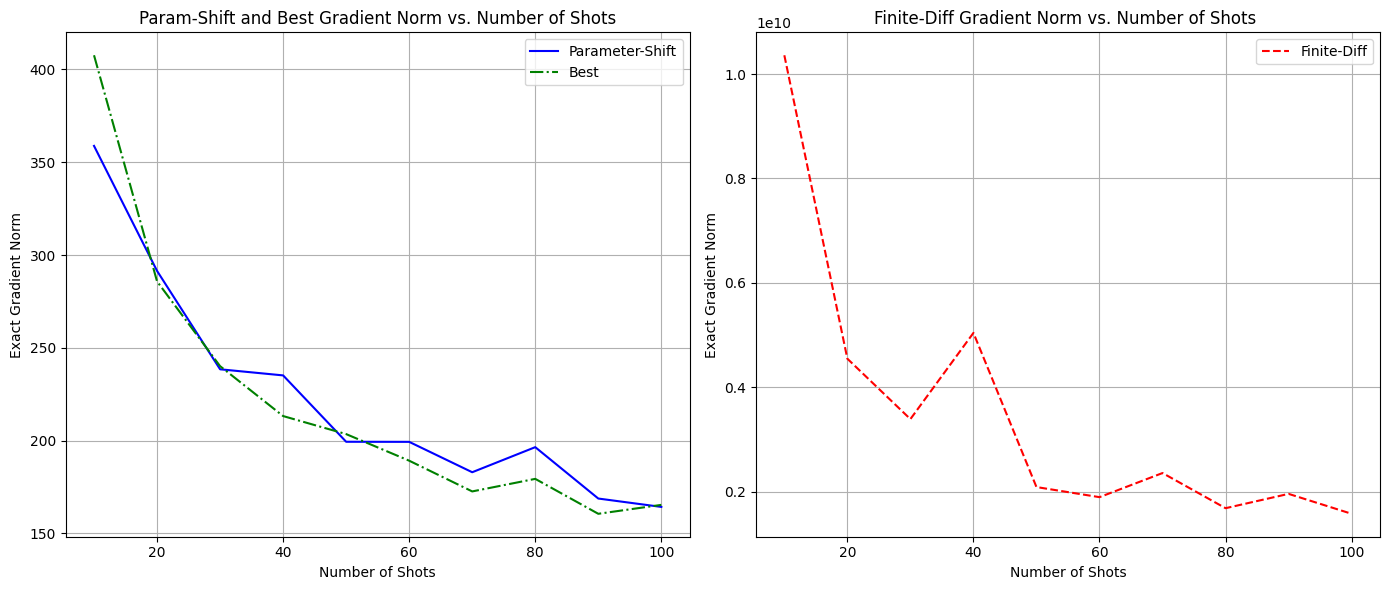

In [ ]:
# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot for the first subplot (parameter-shift and best)
ax1.plot(shots_range, grad_norms_default, linestyle='-', color='b', label='Parameter-Shift')
ax1.plot(shots_range, grad_norms_best, linestyle='-.', color='g', label='Best')
ax1.set_xlabel('Number of Shots')
ax1.set_ylabel('Exact Gradient Norm')
ax1.set_title('Param-Shift and Best Gradient Norm vs. Number of Shots')
ax1.legend()
ax1.grid(True)

# Plot for the second subplot (finite-diff)
ax2.plot(shots_range, grad_norms_finite, linestyle='--', color='r', label='Finite-Diff')
ax2.set_xlabel('Number of Shots')
ax2.set_ylabel('Exact Gradient Norm')
ax2.set_title('Finite-Diff Gradient Norm vs. Number of Shots ')
ax2.legend()
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [12]:
# use jax - jacobian method
def vanilla_grad(init_params,shots):
    init_params = jax.numpy.array(init_params)


    dev = qml.device("default.qubit", shots)

        # Create and return the QNode with the requested differentiation method
    qnode = qml.QNode(circuit, dev, interface="jax")

    grad_fn = jax.jit(jax.jacobian(qnode), static_argnums=1)(init_params, qml.SpecialUnitary )

    # Return the norm of the gradient
    grad_norm = jnp.linalg.norm(grad_fn)

    return grad_norm

c:\Users\DELL\anaconda3\envs\qiskit\Lib\site-packages\jax\_src\lax\lax.py:2745: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)
c:\Users\DELL\anaconda3\envs\qiskit\Lib\site-packages\jax\_src\lax\lax.py:2745: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)
c:\Users\DELL\anaconda3\envs\qiskit\Lib\site-packages\jax\_src\lax\lax.py:2745: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)
c:\Users\DELL\anaconda3\envs\qiskit\Lib\site-packages\jax\_src\lax\lax.py:2745: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)
c:\Users\DELL\anaconda3\envs\qiskit\Lib\site-packages\jax\_src\lax\lax.py:2745: ComplexWarning: 

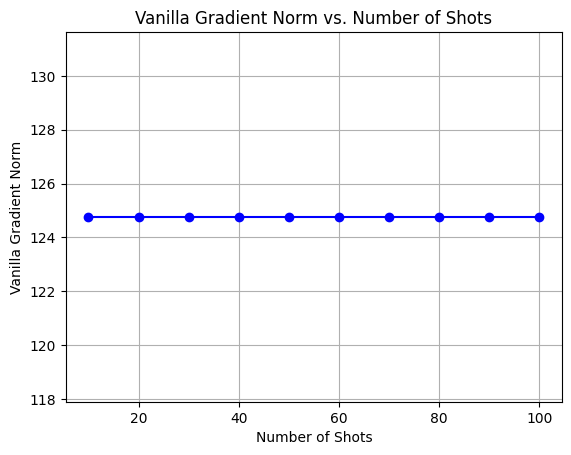

In [13]:
shots_range = np.arange(10, 101, 10)

# Compute the exact gradient norm for each shot count
grad_norms = [vanilla_grad(init_params, shot.item()) for shot in shots_range]

# Plot the results
plt.plot(shots_range, grad_norms, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Shots')
plt.ylabel('Vanilla Gradient Norm')
plt.title('Vanilla Gradient Norm vs. Number of Shots')
plt.grid(True)
plt.show()
